In [14]:
from toolbox.cSection import makeSampleCrossSection
from toolbox.patterns import Patterns
from toolbox.periodic import PeriodicTissue
from toolbox import stress
import matplotlib.pyplot as plt
from toolbox import stress
import os
import numpy as np

import glob
test_sample = "7_mono_0.5_decrease/"
print(sorted(glob.glob("{}cellParameters.*.input".format(test_sample))))



['7_mono_0.5_decrease/cellParameters.0.input', '7_mono_0.5_decrease/cellParameters.1.input', '7_mono_0.5_decrease/cellParameters.10.input', '7_mono_0.5_decrease/cellParameters.11.input', '7_mono_0.5_decrease/cellParameters.12.input', '7_mono_0.5_decrease/cellParameters.13.input', '7_mono_0.5_decrease/cellParameters.14.input', '7_mono_0.5_decrease/cellParameters.15.input', '7_mono_0.5_decrease/cellParameters.16.input', '7_mono_0.5_decrease/cellParameters.17.input', '7_mono_0.5_decrease/cellParameters.18.input', '7_mono_0.5_decrease/cellParameters.19.input', '7_mono_0.5_decrease/cellParameters.2.input', '7_mono_0.5_decrease/cellParameters.20.input', '7_mono_0.5_decrease/cellParameters.21.input', '7_mono_0.5_decrease/cellParameters.22.input', '7_mono_0.5_decrease/cellParameters.23.input', '7_mono_0.5_decrease/cellParameters.24.input', '7_mono_0.5_decrease/cellParameters.25.input', '7_mono_0.5_decrease/cellParameters.3.input', '7_mono_0.5_decrease/cellParameters.4.input', '7_mono_0.5_decre

In [ ]:
## create cross section of a periodic tissue
from toolbox.cSection import makeSampleCrossSection
from toolbox.patterns import Patterns
from toolbox.periodic import PeriodicTissue
from toolbox.minimization import FIREminimization
from toolbox import stress
import matplotlib.pyplot as plt
from toolbox import stress
import os
import numpy as np
import pandas as pd
import glob

dir = "7_bidisperse_5_4.9_0.5_increase/"
# dir = "7_mono_0.5_decrease/"
df = pd.read_csv("{}stresses.csv".format(dir))
print(df["CellID"])
training_cell = df["CellID"].to_numpy()[0]
ids = [int(os.path.basename(f).split(".")[0]) for f in glob.glob("{}*.bulk.txt".format(dir))]
final_iter = max(ids)
file = "{}.bulk.txt".format(final_iter)
sample = PeriodicTissue.from_config(dir,file)
min = FIREminimization.periodic_tissue(sample)
min.load_cell_parameters("cellParameters.{}.input".format(final_iter))

for cellID, cell in sample.cells_.items():
    cell.vtk_scalar_ = cell.s0_
    cell.vtk_scalar_ = stress.calculate_max_shear_stress(sample, cellID)
normal = np.array([1,0,0])
center = sample.cells_[training_cell].center_
print(sample.cells_[training_cell].s0_)
makeSampleCrossSection(sample=min._config, center = center, normal = normal, filename = "cross_section.vtk")
single_cell = sample.extract_cell(training_cell)
makeSampleCrossSection(sample=single_cell, center=center, normal = normal, filename="single_cell_cross_section.vtk")



0    331
Name: CellID, dtype: int64
5.0


In [3]:
from toolbox.cSection import makeSampleCrossSection
from toolbox.patterns import Patterns
from toolbox.periodic import PeriodicTissue
from toolbox.minimization import FIREminimization
from toolbox import stress
import matplotlib.pyplot as plt
from toolbox import stress
import os
import numpy as np
import pandas as pd
import glob
dir = "8_0_5_1_sample/"
df = pd.read_csv("{}stresses.csv".format(dir))
print(df["CellID"])
# ids = [int(os.path.basename(f).split(".")[0]) for f in glob.glob("{}*.bulk.txt".format(dir))]
# ids = sorted(ids)
# final_iter = 33
# for iter in range(final_iter+1):
iter = 33
file = "{}.bulk.txt".format(iter)
sample = PeriodicTissue.from_config(dir,file)
min = FIREminimization.periodic_tissue(sample)
min.load_cell_parameters("cellParameters.{}.input".format(iter))
for i, row in df.iterrows():
    cellID = row["CellID"]
    target_stress = row["Target"]
    cell = sample.cells_[cellID]
    # shear = stress.calculate_max_shear_stress(sample, cellID)
    # cell.max_shear_stress_ = shear
    # vtk_scalar = abs(cell.max_shear_stress_ - target_stress)/ target_stress
    for polygonID in cell.polygons_:
        polygon = sample.polygons_[polygonID]
        # polygon.vtk_scalar_ = vtk_scalar
for cellID in df["CellID"].to_numpy():
    # sample.write_cell_collection_vtk(df["CellID"].to_numpy(),"{}.target_cells.vtk".format(iter),use_scalar=True)
    sample.write_cell_collection_vtk([cellID],"{}.single.vtk".format(cellID),use_scalar=False)



0     11
1    157
2    494
3    166
4    378
Name: CellID, dtype: int64


cellParameters.init.input does not exist


ValueError: Error in tissueSample.Sample: file must exist in self._config_dir

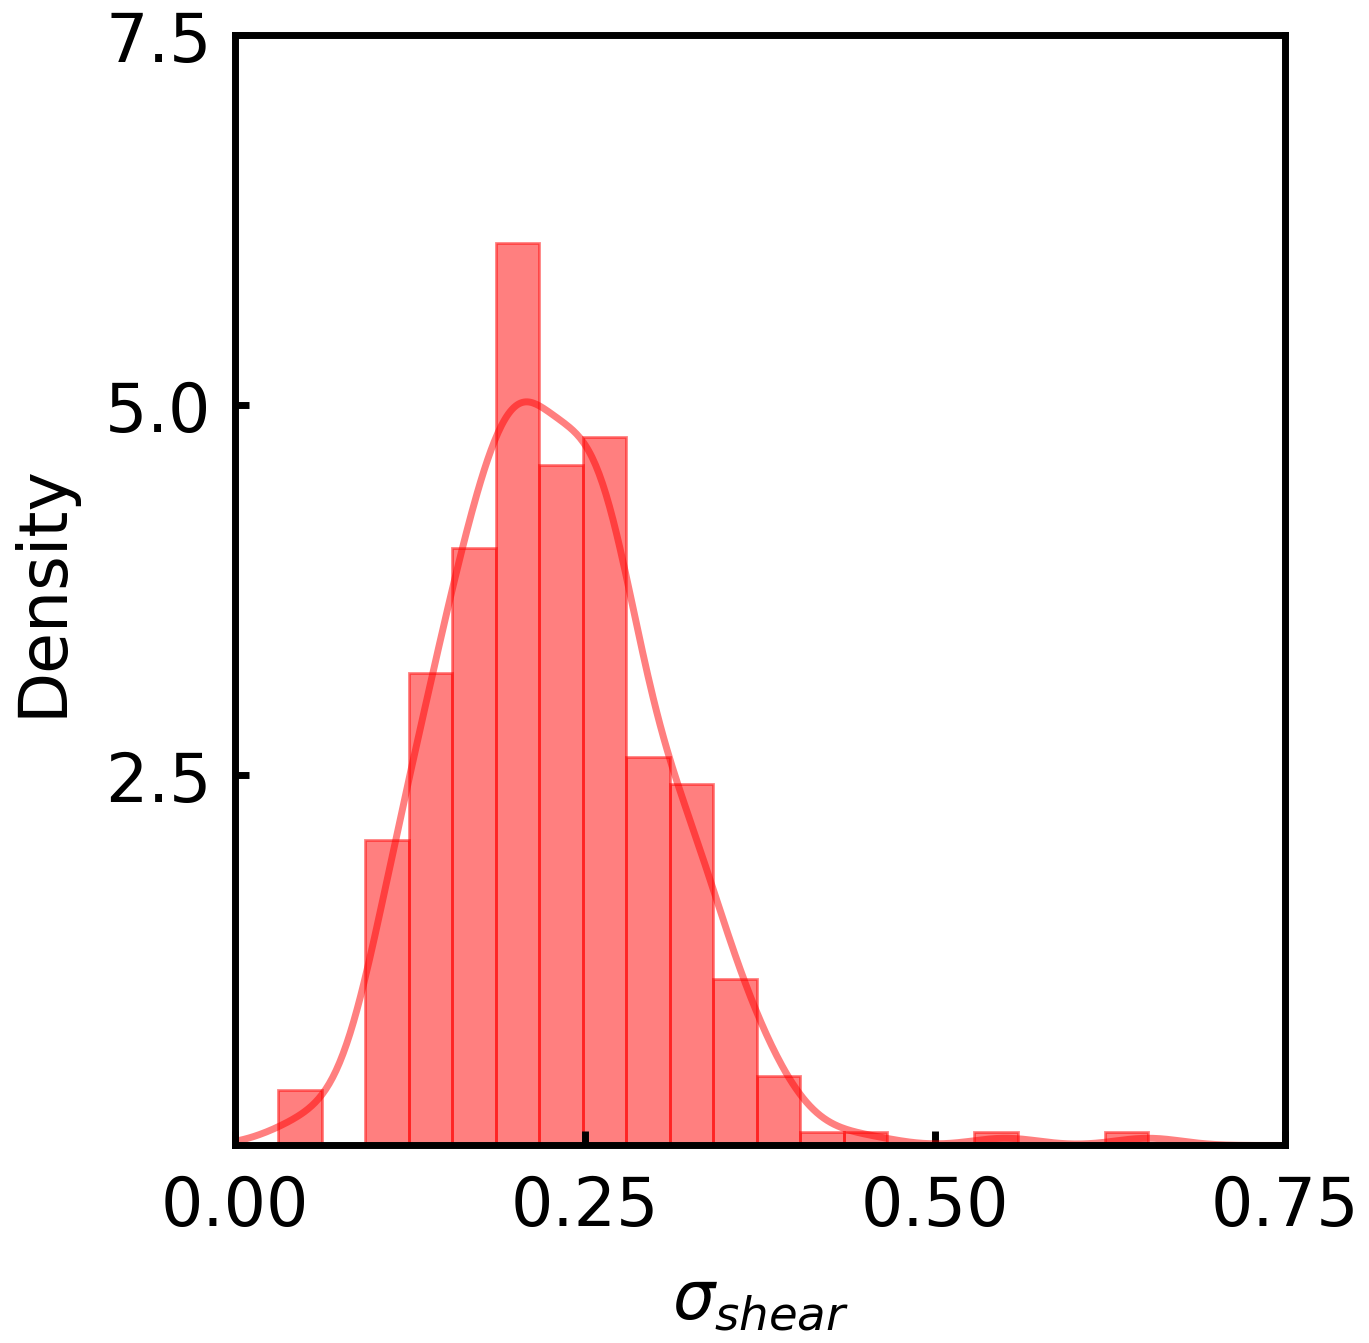

In [16]:
from toolbox import manuscriptPlots
from toolbox.periodic import PeriodicTissue
from toolbox.minimization import FIREminimization
from toolbox import stress
import pandas as pd
import numpy as np

def s0_histogram(dir, final_iter):
    plotter = manuscriptPlots.plot()
    plotter.set_ylim(0,15)
    plotter.set_xlim(4.75,5.25)
    plotter.set_xticks([0.25*i for i in range(150)])
    plotter.set_yticks([5*i for i in range(1,100)])
    plotter.set_xlabel(r"$s_0$")
    plotter.set_yScaled()
    plotter.initialize_figure()
    df = pd.read_csv("{}cellParameters.{}.input".format(dir,final_iter), sep=" ",header=None)
    plotter.histogram_from_dataframe(df[2],color = "blue", bins = 20, label = "_final")
    plotter.save_fig("{}/s0_histogram.png".format(dir))

def combined_stress_histogram(dir, final_iter):
    plotter = manuscriptPlots.plot()
    plotter.set_ylim(0,7.5)
    plotter.set_xlim(0,0.75)
    plotter.set_xticks([0.25*i for i in range(150)])
    plotter.set_yticks([2.5*i for i in range(1,100)])
    plotter.set_xlabel(r"$\sigma_{shear}$")
    plotter.set_yScaled()
    plotter.initialize_figure()

    #init
    file = "init_config.txt"
    sample = PeriodicTissue.from_config(dir, file)
    min = FIREminimization.periodic_tissue(sample)
    min.load_cell_parameters("cellParameters.init.input")
    stresses = []
    for cellID,cell in sample.cells_.items():
        cell.max_shear_stress_ = stress.calculate_max_shear_stress(sample,cellID)
        stresses.append(cell.max_shear_stress_)
    df = pd.DataFrame({"stress": stresses})
    plotter.histogram_from_dataframe(df["stress"],color = "red", bins = 20, label = "initial")

    #final
    file = "{}.bulk.txt".format(final_iter)
    sample = PeriodicTissue.from_config(dir, file)
    min = FIREminimization.periodic_tissue(sample)
    min.load_cell_parameters("cellParameters.{}.input".format(final_iter))
    stresses = []
    for cellID,cell in sample.cells_.items():
        cell.max_shear_stress_ = stress.calculate_max_shear_stress(sample,cellID)
        stresses.append(cell.max_shear_stress_)
    df = pd.DataFrame({"stress": stresses})
    plotter.histogram_from_dataframe(df["stress"],color = "blue", bins = 20, label = "final")
    plotter.save_fig("{}stress_histogram.png".format(dir))

def cost_plot(dir):
    plotter = manuscriptPlots.plot()
    plotter.set_ylim(0,1)
    plotter.set_xlim(0,33)
    plotter.set_xticks([10*i for i in range(150)])
    plotter.set_yticks([.5*i for i in range(1,100)])
    plotter.set_xlabel("Epochs")
    plotter.set_ylabel("Normalized Cost")
    plotter.set_yScaled()
    plotter.initialize_figure()
    array = np.loadtxt("{}costs.txt".format(dir))
    array/=array[0]
    iters = np.arange(len(array))
    plotter.plot_xy(iters, array, color = "blue", label = "_final")
    plotter.save_fig("{}/cost.png".format(dir))


dir = "7_0_new_schema/"
# dir = "7_bidisperse_5_4.9_0.5_decrease/"
final_iter = 33
# s0_histogram(dir, final_iter)
combined_stress_histogram(dir, final_iter)
cost_plot(dir)


